Dataset (first 12 rows)      Genre  Age  Annual Income (k$)  Spending Score (1-100)  Loan Ammount  \
0     Male   40                  15                      39          1200   
1     Male   21                  15                      81          1100   
2   Female   43                  16                       6          1200   
3   Female   23                  16                      77          1300   
4   Female   50                  17                      40          1400   
5   Female   22                  17                      76          1400   
6   Female   40                  18                       6          1500   
7   Female   23                  18                      94          1500   
8     Male   55                  19                       3          1500   
9   Female   30                  19                      72          1500   
10    Male   67                  19                      14          1500   
11  Female   35                  19                 

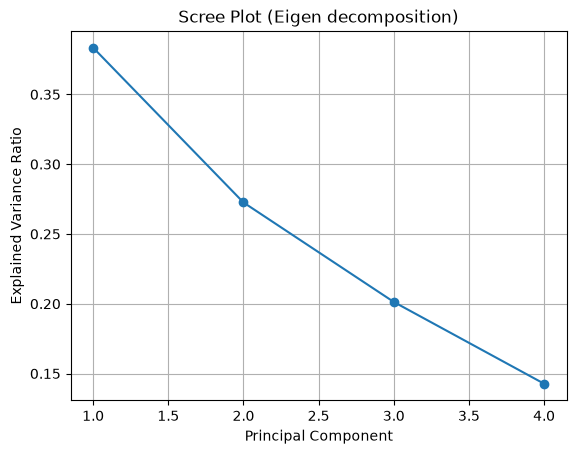

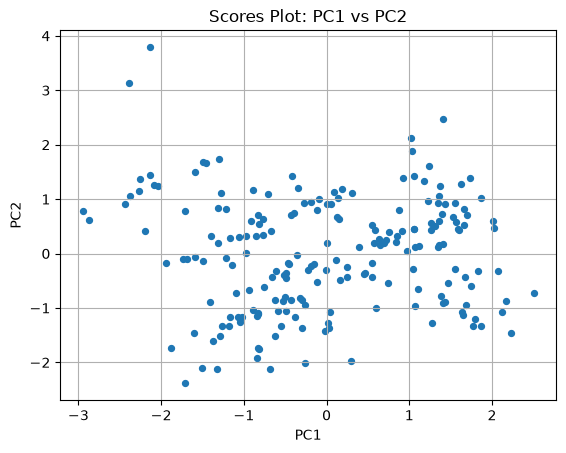

In [1]:
# Biplot 2D (PC1 vs PC2) con PCA
# - Lee S2_Ejemplo.csv
# - Estandariza variables numéricas
# - Calcula PCA (2 componentes)
# - Dibuja puntos (scores) y flechas (loadings)


# ---------- 0) Carga librerías ----------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# ---------- 1) Define el objetivo del análisis ----------
# Objective: Reduce dimensionality, visualize structure, and prepare features for ML using PCA.


# ---------- 2) Cargar y preparar los datos (Load and data preparation) ----------
path = "S2_Ejemplo.csv"
df = pd.read_csv(path)

num_df = df.select_dtypes(include=[np.number]).copy()
shape_report = pd.DataFrame({
    "metric": ["rows_total", "cols_total", "cols_numeric"],
    "value": [df.shape[0], df.shape[1], num_df.shape[1]]
})

num_df_imputed = num_df.fillna(num_df.mean(numeric_only=True))

print("Dataset (first 12 rows)", df.head(12))
print("Numeric subset after mean-imputation (first 12 rows)", num_df_imputed.head(12))
print("Shape report", shape_report)


# ---------- 3) Estandarizar las variables (Standarize variables Z-score) ----------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(num_df_imputed.values)
scaled_df = pd.DataFrame(X_scaled, columns=num_df_imputed.columns, index=num_df_imputed.index)


# ---------- 4) Construir la matriz de correlación o covarianza (correlation matrix) ----------
corr_matrix = np.corrcoef(X_scaled, rowvar=False)
corr_df = pd.DataFrame(corr_matrix, index=num_df_imputed.columns, columns=num_df_imputed.columns)
print("Correlation matrix (numeric features)", corr_df.round(3))


# ---------- 5) Calcular autovalores y autovectores (eigen decompotition) ----------
eig_vals, eig_vecs = np.linalg.eig(corr_matrix)
idx_sorted = np.argsort(eig_vals)[::-1]
eig_vals_sorted = eig_vals[idx_sorted].real
eig_vecs_sorted = eig_vecs[:, idx_sorted].real

total_var = eig_vals_sorted.sum().real
explained_ratio_eig = (eig_vals_sorted / total_var).real
cum_explained_eig = np.cumsum(explained_ratio_eig)

eig_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(eig_vals_sorted))],
    "eigenvalue": eig_vals_sorted,
    "explained_variance_ratio": explained_ratio_eig,
    "cumulative_explained_variance": cum_explained_eig
})
print("Eigen decomposition summary (from correlation matrix)", eig_summary.round(4))


# ---------- 6) Seleccionar número de componentes principales (Kaiser and 75% cumulative) ----------
kaiser_mask = eig_vals_sorted > 1.0
n_kaiser = int(kaiser_mask.sum())
n_cum = int(np.argmax(cum_explained_eig >= 0.75) + 1) if len(eig_vals_sorted) > 0 else 0
n_components = max(n_kaiser, n_cum) if n_cum > 0 else n_kaiser if n_kaiser > 0 else min(2, len(eig_vals_sorted))

selection_report = pd.DataFrame({
    "criterion": ["Kaiser (>1.0)", "Cumulative >= 0.75", "Final chosen n_components"],
    "value": [n_kaiser, n_cum, n_components]
})
print("Component selection report", selection_report)


# ---------- 7) Calcular los componentes principales (Fit PCA) ----------
pca = PCA(n_components=n_components, svd_solver="full")


X_pca = pca.fit_transform(X_scaled)

explained_ratio = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained_ratio)

pca_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(n_components)],
    "explained_variance_ratio": explained_ratio,
    "cumulative_explained_variance": cum_explained
})
print("PCA summary (scikit-learn)", pca_summary.round(4))

loadings = pd.DataFrame(
    pca.components_.T,
    index=num_df_imputed.columns,
    columns=[f"PC{i+1}" for i in range(n_components)]
)
print("PCA loadings (feature contributions)", loadings.round(4))

pca_scores_df = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(n_components)], index=num_df_imputed.index)
#scores_path = "/mnt/data/S2_Ejemplo_PCA_scores.csv"
pca_scores_df.to_csv("S2_Ejemplo_PCA_scores.csv", index=False)


# ---------- 8) Visualizar e interpretar los resultados (visualize and interpret the results) ----------
plt.figure()
plt.plot(range(1, len(eig_vals_sorted) + 1), explained_ratio_eig, marker="o")
plt.title("Scree Plot (Eigen decomposition)")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.show()

if n_components >= 2:
    plt.figure()
    plt.scatter(X_pca[:, 0], X_pca[:, 1], s=18)
    plt.title("Scores Plot: PC1 vs PC2")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()


In [2]:
# ---------- 9) Aplicar PCA en el contexto del negocio (applying PCA in the business context) ----------

# Use PCs for segmentation, visualization, or as features in predictive models.



# =======================
# SEGMENTACIÓN CON KMEANS
# =======================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# Usaremos las 2-3 primeras PCs (ajusta según tu selección)
Z = X_pca[:, :2] # por ejemplo, PC1 y PC2

# 1) Búsqueda rápida de k con codo y silhouette
inertias = []
sil_scores = []

K = range(2, 10)
for k in K:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(Z)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(Z, labels))

print("k vs inertia:", list(zip(K, inertias)))
print("k vs silhouette:", list(zip(K, np.round(sil_scores, 3))))

# 2) Entrena el modelo final con el k elegido (por ejemplo, el mejor silhouette)
k_best = K[int(np.argmax(sil_scores))]
kmeans = KMeans(n_clusters=k_best, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(Z)

print(f"Clusters asignados con k={k_best}. Silhouette={max(sil_scores):.3f}")

# 3) Anexar clusters a tu dataframe original
df_clusters = df.copy()
df_clusters["cluster"] = cluster_labels
print(df_clusters.head())

# (Opcional) Guardar resultados
df_clusters.to_csv("clientes_con_clusters.csv", index=False)
#Tip: si tu PC3 agrega información útil, usa Z = X_pca[:, :3] y evalúa nuevamente.


k vs inertia: [(2, 293.2720126823971), (3, 184.0652639072207), (4, 137.19583991783534), (5, 108.20310471467074), (6, 89.48546593268121), (7, 75.57232030968363), (8, 63.511939874218434), (9, 54.546739010100836)]
k vs silhouette: [(2, np.float64(0.407)), (3, np.float64(0.435)), (4, np.float64(0.426)), (5, np.float64(0.411)), (6, np.float64(0.407)), (7, np.float64(0.412)), (8, np.float64(0.402)), (9, np.float64(0.414))]
Clusters asignados con k=3. Silhouette=0.435
    Genre  Age  Annual Income (k$)  Spending Score (1-100)  Loan Ammount  \
0    Male   40                  15                      39          1200   
1    Male   21                  15                      81          1100   
2  Female   43                  16                       6          1200   
3  Female   23                  16                      77          1300   
4  Female   50                  17                      40          1400   

       LoanID   Device Location  cluster  
0  13e3dfdf97  Android    Rural   

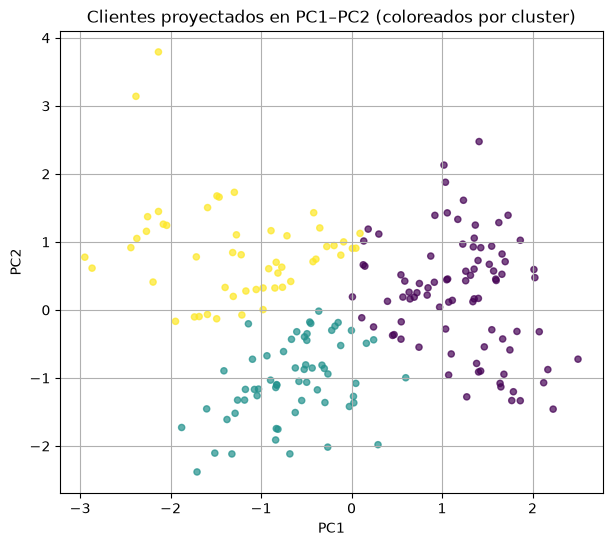

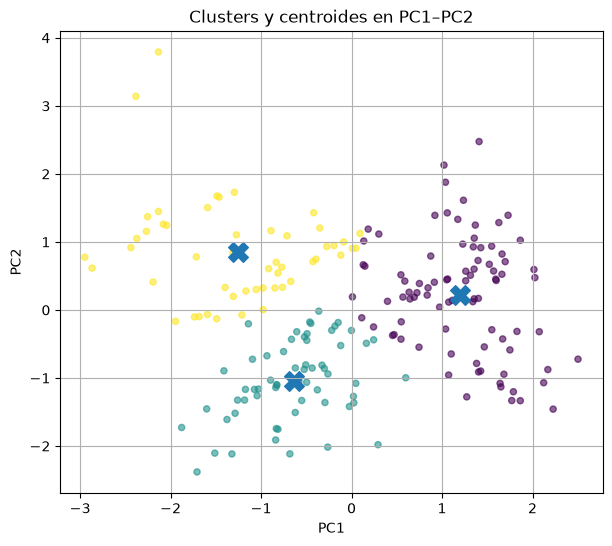

In [3]:
# ==========================
# VISUALIZACIÓN DE CLUSTERS
# ==========================
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, s=20, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clientes proyectados en PC1–PC2 (coloreados por cluster)")
plt.grid(True)
plt.show()

#Marcar centroides:
centroids = kmeans.cluster_centers_
plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, s=20, alpha=0.6)
plt.scatter(centroids[:,0], centroids[:,1], s=200, marker='X')
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("Clusters y centroides en PC1–PC2"); plt.grid(True)
plt.show()
